# ITAI 4374: Neuroscience as a Model for AI
## Module 02 Lab: Cortical Column Voting Simulation

---

# Meet DJ CorTex

Welcome to the **L02 Cortical Column Voting Simulation**, where neuroscience meets the streets of Houston.

Meet **DJ CorTex**, a country brain straight outta Houston. DJ CorTex represents a simplified network of cortical columns working together to figure out what the brain is seeing. In this simulation, each cortical column gets a piece of noisy sensory information. Instead of every column knowing the answer by itself, each one keeps its own guess, compares guesses, and votes with the crew.

DJ CorTex is built on the core concept of the **Thousand Brains Theory**: the brain does not depend on a single location to recognize objects. Instead, multiple columns build individual representations and contribute to a unified, distributed understanding.

### Model Assumptions & Rules
* **The Five Possible Answers:** `["cup", "ball", "book", "phone", "apple"]`[cite: 5]
* **Noisy Inputs:** Uniform random noise simulates real-world unreliable sensory data.
* **Vote Weight ($w$):** Controls how heavily columns balance individual evidence versus group consensus.
* **Consensus Threshold:** Reached when an object hypothesis hits **90% confidence** (capped at 20 rounds).

### The Voting Equation Explained
At each voting round, every column updates its belief using:

$$B_{\text{new}} = (1 - w)E + w\bar{B}$$

Where $E$ is local evidence, $\bar{B}$ is population belief, and $w$ is the vote weight. Beliefs are then **squared (sharpened)** and **normalized** so row probabilities sum back to `1.0`.

In [139]:
########
# SETUP #
########
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, HTML, display
import time

# setting seed
np.random.seed(42)

# objects
OBJECTS = ["cup", "ball", "book", "phone", "apple"]
NUM_OBJECTS = len(OBJECTS)

PINK = '\033[95m'
RESET = '\033[0m'

print("Setup complete!")
print("Objects:", OBJECTS)

Setup complete!
Objects: ['cup', 'ball', 'book', 'phone', 'apple']


In [140]:
def create_sensory_input(true_object, num_columns, noise_level=0.3):
    """
    Creates the sensory input matrix, filling it with noise and injecting
    a true signal, then normalizing rows into a probability distribution.
    """
    np.set_printoptions(precision=3, suppress=True)

    # Panel 1: System Boot Sequence
    display_comic_panel_html(
        1,
        "System Boot Sequence",
        swag_walk,
        "def create_sensory_input(true_object, num_columns, noise_level=0.3):",
        None,
        "DJ Cortex entering the mainframe. Setting up the sensory input matrix grid."
    )

    # matrix
    evidence = np.random.uniform(
        0,
        noise_level,
        size=(num_columns, NUM_OBJECTS)
    )

    # Panel 2: Bringing the Noise
    display_comic_panel_html(
        2,
        "Bringing the Noise",
        swag_explain,
        "evidence = np.random.uniform(0, noise_level, size=(num_columns, NUM_OBJECTS))",
        np.array(evidence).T,  # <-- flip .T
        "Flooding the matrix with random static. We transposed it (.T) for the screen so the 6 Cortical Columns actually look like vertical columns!"
    )

    # true-object signal to every column at once
    signals = np.random.uniform(0.15, 0.45, size=num_columns)
    evidence[:, true_object] += signals

    # Panel 3: Dropping the Truth
    display_comic_panel_html(
        3,
        f"Dropping the Truth on {OBJECTS[true_object].upper()}",
        swag_walk,
        "signals = np.random.uniform(0.15, 0.45, size=num_columns)\nevidence[:, true_object] += signals",
        np.array(evidence).T,  # <-- flip .T
        f"Injected a stronger sensory signal into the true object index ({OBJECTS[true_object]})."
    )

    # normalize
    row_sums = np.sum(evidence, axis=1, keepdims=True)
    evidence = evidence / row_sums

    # Panel 4: Squishing the Stats
    display_comic_panel_html(
        4,
        "Squishing the Stats",
        swag_explain,
        "row_sums = np.sum(evidence, axis=1, keepdims=True)\nevidence = evidence / row_sums",
        np.array(evidence).T,  # <-- .T FLIPS IT FOR DISPLAY
        "Normalizing the math so each cortical column's probabilities sum exactly to 1.0."
    )

    return evidence

# baseline-sensory
true_object_idx = 0
num_columns = 6
final_evidence = create_sensory_input(true_object=true_object_idx, num_columns=num_columns, noise_level=0.3)

# Baseline Experiment

Before we turn up the noise or bring more columns into the crew, DJ CorTex starts with a basic setup. This gives us a starting point that we can use to compare the results of the later experiments.

For the baseline simulation, the crew uses these settings:

| Setting | Value | Description |
|---|---:|---|
| True Object | `cup` | The correct answer is a cup. |
| Columns | `6` | Six cortical columns are working together. |
| Noise Level | `0.3` | The sensory information has a moderate amount of random noise. |
| Vote Weight | `0.3` | Each column gives some influence to the other columns while still relying more on its own sensory evidence. |
| Maximum Rounds | `20` | The columns can continue voting for up to 20 rounds. |
| Consensus Threshold | `0.90` | The crew is considered to have reached consensus when the strongest answer reaches 90% confidence. |

This baseline gives DJ CorTex a normal starting point. Once we see how the crew performs under these conditions, we can change one part of the setup at a time and see what happens.

In [141]:
def initialize_beliefs(evidence):
    return evidence.copy()

def voting_round(beliefs, evidence, vote_weight=0.3):
    average_neighbor_votes = np.mean(beliefs, axis=0)
    new_belief = (1 - vote_weight) * evidence + vote_weight * average_neighbor_votes
    new_belief = new_belief ** 2
    row_sums = np.sum(new_belief, axis=1, keepdims=True)
    return new_belief / row_sums

def run_voting(evidence, max_iterations=20, vote_weight=0.3, consensus_threshold=0.9):
    beliefs = initialize_beliefs(evidence)
    history = [beliefs.copy()]
    iterations_used = 0

    for i in range(max_iterations):
        iterations_used += 1
        beliefs = voting_round(beliefs, evidence, vote_weight)
        history.append(beliefs.copy())

        mean_beliefs = np.mean(beliefs, axis=0)
        current_agreement = np.max(mean_beliefs)
        if current_agreement >= consensus_threshold:
            break

    final_mean_beliefs = np.mean(beliefs, axis=0)
    final_object = int(np.argmax(final_mean_beliefs))
    final_confidence = float(np.max(final_mean_beliefs))

    return history, final_object, final_confidence, iterations_used

# run baseline
history, final_obj, final_conf, iters = run_voting(final_evidence)

# Baseline Results

Here is what happened when DJ CorTex ran the simulation with the normal starting settings:

| What We Measured | What Happened |
|---|---|
| Correct object | `cup` |
| Number of columns | `6` |
| Noise level | `0.3` |
| Vote weight | `0.3` |
| Final answer | `cup` |
| Final confidence | `75.42%` |
| Voting rounds | `20` |
| Did the crew reach 90% confidence? | No |

## What Does This Tell Us?

DJ CorTex's crew picked the correct object, the **cup**, but they were not confident enough to reach the 90% consensus goal.

The crew used all 20 available voting rounds, but their final confidence was 75.42%. Since 75.42% is below the 90% target, the simulation stopped because it reached the maximum number of rounds.

So, the baseline result is simple:

> The crew got the right answer, but they were not confident enough to call it a strong consensus.

This gives us a useful starting point for the experiments that follow.

###### Note on Interpretation

The network selected **`cup`** as its final hypothesis, but it did not reach the 90% consensus threshold within the allowed 20 rounds.

# Experiment 1 — High Noise

To evaluate the model's robustness, we increase the noise level to:

```python
noise_level = 0.8
```

The simulation is run for **30 trials**, and its performance is compared against the baseline experiment.

This experiment helps answer an important question:

> Can DJ CorTex and the cortical crew still identify the correct object when the sensory information becomes highly unreliable?

In [142]:
def run_trials(num_trials=30, num_cols=6, noise=0.3, true_obj=0):
    correct_count = 0
    confidences = []
    rounds_list = []

    for _ in range(num_trials):
        ev = np.random.uniform(0, noise, size=(num_cols, NUM_OBJECTS))
        for c in range(num_cols):
            ev[c, true_obj] += np.random.uniform(0.15, 0.45)
        ev /= np.sum(ev, axis=1, keepdims=True)

        _, win_obj, conf, iters = run_voting(ev)
        if win_obj == true_obj:
            correct_count += 1
        confidences.append(conf)
        rounds_list.append(iters)

    accuracy = correct_count / num_trials
    return accuracy, np.mean(confidences), np.mean(rounds_list)

baseline_acc, baseline_conf, baseline_rounds = run_trials(num_trials=30, num_cols=6, noise=0.3, true_obj=0)
high_noise_acc, high_noise_conf, high_noise_rounds = run_trials(num_trials=30, num_cols=6, noise=0.8, true_obj=0)

print(f"Baseline (Noise=0.3) -> Accuracy: {baseline_acc:.2f}, Conf: {baseline_conf:.2f}, Rounds: {baseline_rounds:.1f}")
print(f"High Noise (Noise=0.8) -> Accuracy: {high_noise_acc:.2f}, Conf: {high_noise_conf:.2f}, Rounds: {high_noise_rounds:.1f}")

Baseline (Noise=0.3) -> Accuracy: 1.00, Conf: 0.82, Rounds: 19.5
High Noise (Noise=0.8) -> Accuracy: 0.97, Conf: 0.56, Rounds: 20.0


In [143]:
def display_exam_panel(true_object, evidence):
    results_list_html = ""
    for i in range(evidence.shape[0]):
        best = OBJECTS[np.argmax(evidence[i])]
        conf = np.max(evidence[i]) * 100
        results_list_html += f"<div style='color: #f8f8f2; font-size: 11px;'>Column {i}: <span style='color: #50fa7b; font-weight: bold;'>{best.upper()}</span> ({conf:.1f}% confidence)</div>"

    exam_html = f"""
    <div style="background-color: #1e1e1e; border: 2px solid #bd93f9; border-radius: 10px; padding: 12px; font-family: monospace; margin-bottom: 15px; box-shadow: 0 4px 6px rgba(0,0,0,0.3);">
        <div style="color: #50fa7b; font-weight: bold; font-size: 14px; border-bottom: 1px solid #444; padding-bottom: 5px; margin-bottom: 10px;">
            PANEL 5: EXAM TIME (TESTING THE MATRIX)
        </div>
        <div style="display: flex; flex-direction: row; align-items: flex-start; gap: 15px;">
            <div style="flex: 0 0 auto;">
                <pre style="color: {PINK}; background-color: #282a36; padding: 10px; border-radius: 6px; font-size: 12px; line-height: 1.1; margin: 0;">{swag_explain.strip()}</pre>
            </div>
            <div style="flex: 1; display: flex; flex-direction: column; justify-content: space-between;">
                <div>
                    <span style="color: #ff79c6; font-weight: bold; font-size: 11px;">TEST RESULTS OVERVIEW:</span>
                    <div style="color: #8be9fd; font-size: 11px; margin-top: 3px;">True object: <b style="color: #f8f8f2;">{OBJECTS[true_object].upper()}</b> | Shape: {evidence.shape}</div>
                    <div style="margin-top: 6px; border-top: 1px solid #333; padding-top: 4px;">{results_list_html}</div>
                </div>
                <div style="margin-top: 10px; border-top: 1px dashed #444; padding-top: 8px;">
                    <span style="color: #ff79c6; font-weight: bold; font-size: 11px;">REAL TALK:</span>
                    <p style="color: #8be9fd; font-style: italic; font-size: 12px; margin: 2px 0 0 0;">We fed the finalized matrix through argmax to see what each column thinks it sees.</p>
                </div>
            </div>
        </div>
    </div>
    """
    display(HTML(exam_html))

display_exam_panel(true_object_idx, final_evidence)

Experiment 2 — More Columns
Increasing column count from 6 to 20 tests population-level robustness.

In [144]:
more_cols_acc, more_cols_conf, more_cols_rounds = run_trials(num_trials=30, num_cols=20, noise=0.3, true_obj=0)

# Baseline vs. More Columns

Now DJ CorTex changes one thing: the size of the crew.

The baseline uses **6 columns**. The second experiment uses **20 columns**. Everything else stays the same so we can see whether having more columns helps the group make a better decision.

| Condition | Crew Size | Accuracy | Confidence | Average Rounds |
|---|---:|---:|---:|---:|
| Baseline | 6 | `1.00` | `0.82` | `19.5` |
| More columns | 20 | `0.97` | `0.78` | `18.2` |
## What Are We Looking For?

The main question is:

> Does a bigger cortical crew make a better decision?

We can compare the two groups by looking at:

- **Accuracy:** Did the crew choose the correct object?
- **Confidence:** How strongly did the crew agree on its answer?
- **Average rounds:** How many voting rounds did the crew need?

If the 20-column group performs better, that would suggest that having more independent columns can help the system handle uncertain or noisy information.

If the results do not improve, that is important too. More columns do not automatically mean a better answer. The quality of the information and the way the columns influence each other still matter.

DJ CorTex is about to find out whether more voices actually make the crew smarter.

---
## What the More Columns Experiment Shows

DJ CorTex's experiment demonstrates a simple idea: when more independent columns contribute to a decision, the group may be better able to handle noisy information from any one column.

In other words, one column might get a bad signal, but the rest of the crew can help balance it out.

This does not mean that simply adding more columns makes the system work like a real brain. The biological cortex is much more complicated than the simple averaging and voting used in this simulation.

For DJ CorTex, the important lesson is:

> More voices can make a group decision more stable, but how those voices communicate still matters.

# Experiment 3 — Vote-Weight Sweep

Now DJ CorTex changes another part of the voting system: how much each column listens to the crew.

Instead of using just one vote weight, the simulation tests five different values:

```python
[0.1, 0.3, 0.5, 0.7, 0.9]
```

The vote weight controls how strongly a column is influenced by the beliefs of the other columns.

| Vote Weight | What It Means |
|---:|---|
| `0.1` | The column mostly trusts its own sensory evidence. |
| `0.3` | The column gives some influence to the crew. |
| `0.5` | The column gives equal weight to its own evidence and the population vote. |
| `0.7` | The column listens more strongly to the crew. |
| `0.9` | The population vote has very strong influence over the column's decision. |

DJ CorTex is basically asking the same question five different ways:

> Should the columns trust what they see, or trust what the crew is saying?

By sweeping through these vote weights, we can see how sensitive the simulation is to this parameter. For each setting, we can compare the system's:

- **Accuracy:** Whether the final answer matches the correct object.
- **Final confidence:** How strongly the population agrees with the selected answer.
- **Voting rounds:** How many rounds the system needs before reaching consensus or stopping at the maximum round limit.

This helps us look for a balance between individual evidence and group agreement. A column that relies too heavily on itself may have trouble overcoming noisy information. On the other hand, a column that relies too heavily on the group could allow an incorrect belief to spread through the entire crew.

The goal is not simply to find the biggest vote weight. The goal is to see which balance gives DJ CorTex's crew the most reliable result.

In [145]:
weights = [0.1, 0.3, 0.5, 0.7, 0.9]
sweep_results = []

print(f"{'Weight':<8} {'Result':<8} {'Conf':<10} {'Iters':<8} {'Correct'}")
print("-" * 45)

for w in weights:
    np.random.seed(42)
    # Generate test evidence for this run
    ev = np.random.uniform(0, 0.3, size=(6, NUM_OBJECTS))
    for c in range(6):
        ev[c, 0] += np.random.uniform(0.15, 0.45)
    ev /= np.sum(ev, axis=1, keepdims=True)

    # Run voting with the specific vote weight
    _, res, conf, iters = run_voting(ev, vote_weight=w)

    obj_name = OBJECTS[res]
    correct = "Yes" if res == 0 else "No"

    sweep_results.append((w, obj_name, conf, iters, correct))
    print(f"{w:<8} {obj_name:<8} {conf*100:>5.1f}%    {iters:<8} {correct}")

Weight   Result   Conf       Iters    Correct
---------------------------------------------
0.1      cup       64.0%    20       Yes
0.3      cup       77.7%    20       Yes
0.5      cup       90.9%    4        Yes
0.7      cup       96.2%    3        Yes
0.9      cup       92.6%    2        Yes


# Improved Visualization with True Object & Threshold Markers

DJ CorTex has the crew voting, but numbers alone do not tell the whole story. We also need a way to see what happens during the voting process.

This improved visualization tracks the system's confidence from one voting round to the next. It also adds two important reference points:

- **True Object:** Shows which object the simulation is actually trying to identify.
- **90% Threshold:** Shows the confidence level required for the crew to declare a strong consensus.

The true object gives us a way to compare the crew's decision with the correct answer. The 90% threshold gives us a clear target for determining whether the columns have reached strong agreement.

This makes it easier to see whether DJ CorTex's crew:

- Moves toward the correct object.
- Becomes more confident over time.
- Reaches the 90% consensus threshold.
- Gets stuck below the threshold.
- Converges toward an incorrect answer.

The visualization is especially useful when comparing the baseline, high-noise, more-column, and vote-weight experiments. Instead of looking at each final number separately, we can watch how the crew's decision develops round by round.

For DJ CorTex, the chart is like watching the whole crew argue their way toward an answer. The important question is not only where they finish, but also how they got there.

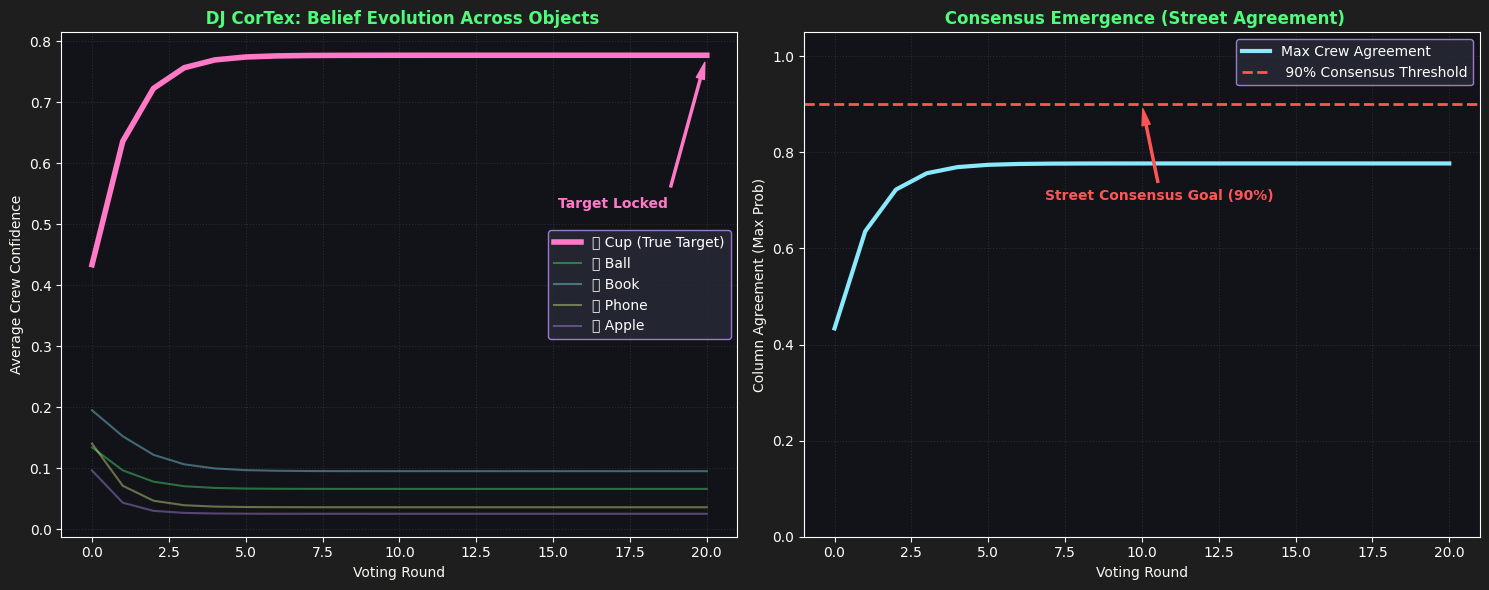

In [146]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

def visualize_consensus_enhanced(history, true_object):
    history_np = np.array(history)
    iterations = history_np.shape[0]
    avg_confidence = np.mean(history_np, axis=1)

    # dark theme
    plt.style.use('dark_background')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    fig.patch.set_facecolor('#1e1e1e')
    ax1.set_facecolor('#121319')
    ax2.set_facecolor('#121319')

    neon_colors = ['#ff79c6', '#50fa7b', '#8be9fd', '#f1fa8c', '#bd93f9']

    # ----------
    # left plot
    # ----------
    for obj_idx in range(NUM_OBJECTS):
        is_true = (obj_idx == true_object)
        label_str = f"🎤 {OBJECTS[obj_idx].capitalize()} (True Target)" if is_true else f"🔍 {OBJECTS[obj_idx].capitalize()}"
        lw = 4.0 if is_true else 1.5
        alpha = 1.0 if is_true else 0.4
        color = '#ff79c6' if is_true else neon_colors[obj_idx % len(neon_colors)]

        ax1.plot(range(iterations), avg_confidence[:, obj_idx], label=label_str, linewidth=lw, alpha=alpha, color=color)

    # annotation (pointing to the true target's trend)
    final_true_conf = avg_confidence[-1, true_object]
    ax1.annotate(
        " Target Locked",
        xy=(iterations - 1, final_true_conf),
        xytext=(max(0, iterations - 6), final_true_conf - 0.25),
        arrowprops=dict(facecolor='#ff79c6', shrink=0.05, width=1.5, headwidth=6, edgecolor='#ff79c6'),
        color='#ff79c6', fontsize=10, fontweight='bold'
    )

    ax1.set_title(' DJ CorTex: Belief Evolution Across Objects', color='#50fa7b', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Voting Round', color='#f8f8f2')
    ax1.set_ylabel('Average Crew Confidence', color='#f8f8f2')
    ax1.legend(facecolor='#282a36', edgecolor='#bd93f9', labelcolor='white')
    ax1.grid(True, color='#444444', linestyle=':', alpha=0.5)

    # ----------
    # right plot
    # ----------
    max_agreement = np.max(avg_confidence, axis=1)
    ax2.plot(range(iterations), max_agreement, color='#8be9fd', linewidth=3.0, label='Max Crew Agreement')
    ax2.axhline(y=0.9, color='#ff5555', linestyle='--', linewidth=2.0, label=' 90% Consensus Threshold')

    # annotation (pointing to the 90% threshold line)
    mid_point = iterations // 2
    ax2.annotate(
        "Street Consensus Goal (90%)",
        xy=(mid_point, 0.9),
        xytext=(mid_point - (iterations * 0.15), 0.7),
        arrowprops=dict(facecolor='#ff5555', shrink=0.05, width=1.5, headwidth=6, edgecolor='#ff5555'),
        color='#ff5555', fontsize=10, fontweight='bold'
    )

    ax2.set_title(' Consensus Emergence (Street Agreement)', color='#50fa7b', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Voting Round', color='#f8f8f2')
    ax2.set_ylabel('Column Agreement (Max Prob)', color='#f8f8f2')
    ax2.set_ylim(0, 1.05)
    ax2.legend(facecolor='#282a36', edgecolor='#bd93f9', labelcolor='white')
    ax2.grid(True, color='#444444', linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

# visualize
visualize_consensus_enhanced(history, true_object=0)

# Self-Reflection & Analysis

After putting DJ CorTex's cortical crew through the different experiments, I started to see the simulation less as a simple voting program and more as a way to think about how distributed decision-making can work. The experiments changed three major things: the amount of noise in the sensory information, the number of columns participating in the decision, and how strongly each column listened to the rest of the population. Looking at these changes together helped me understand both the strengths and weaknesses of a distributed system.

## Noise and Reliability

The first thing I noticed was the effect of noise. When the noise level increased, the sensory information became less reliable and the probability distributions became more spread out across the possible objects. This lowered the confidence of the columns and made incorrect classifications more likely.

Noise also made consensus harder because different columns could receive different corrupted versions of the same sensory information. DJ CorTex's crew could still communicate with each other, but communication cannot completely fix unreliable information coming into the system.

At moderate noise levels, the population could remain reasonably robust because individual errors could be balanced by information from other columns. However, extreme noise eventually degraded the system's performance. This showed me that population averaging can reduce some errors, but it cannot completely remove bad information.

## More Columns and Stability

The second experiment showed what happens when the crew gets bigger. Increasing the number of columns from `6` to `20` gave the system more independent observations to work with.

If one column received an unusual or misleading signal, the other columns could help balance it out. This made the population estimate more stable and reduced the effect of individual anomalies. In simple terms, DJ CorTex had more voices to compare before settling on an answer.

This connects to the much larger scale of the biological cortex, which is estimated to contain approximately `150,000` cortical columns. A population on that scale could support massive parallel processing and a high degree of fault tolerance.

However, I do not think the experiment means that simply adding more columns automatically makes a system more intelligent. A larger network also requires more computation and coordination. If many columns become influenced by the same incorrect belief, the larger population can actually help spread that mistake.

## The Vote-Weight Balance

The vote-weight experiment was especially interesting because it showed that communication itself has to be balanced.

With a low `vote_weight`, such as `0.1`, each column mostly trusts its own sensory evidence. This preserves individual information, but the columns do not benefit as much from the rest of the crew.

With a very high `vote_weight`, such as `0.9`, the population has much more influence over each individual column. This can produce faster agreement, but it also creates a greater risk of groupthink. If the population starts moving toward the wrong object, strong peer influence can cause that incorrect belief to spread through the network.

An intermediate value, such as `0.3` to `0.5`, provides a better balance between preserving local evidence and allowing useful information from the other columns to influence the decision.

## Speed, Accuracy, and Consensus

This also showed me that there is a difference between speed and accuracy. A system that reaches agreement quickly is not necessarily performing better than one that takes longer to reach the correct answer.

Stronger peer influence can accelerate convergence because each column is more strongly affected by the population's current belief. The problem is that the same mechanism that spreads a correct belief quickly can also spread an incorrect one quickly.

DJ CorTex's crew therefore has to balance two questions:

1. How quickly can the crew agree?
2. How confident should we be that the agreement is actually correct?

That leads to one of the most important results of the entire simulation:

> Consensus does not always mean truth.

Under high noise or misleading initial conditions, the columns can potentially converge on the wrong hypothesis. Once enough columns support that hypothesis, peer voting can reinforce it throughout the population.

Everyone agreeing does not guarantee that everyone is right. This is important because it means that accuracy, confidence, noise level, vote weight, and convergence speed should all be considered when evaluating the system instead of treating consensus by itself as proof of success.

## Connection to Thousand Brains Theory

The simulation also helped me understand the connection to the Thousand Brains Theory. The idea of using multiple cortical columns relates to the broader concept of distributed representation, where knowledge is not necessarily dependent on one single location.

In this simulation, each column has its own evidence and hypothesis, and the population works toward a shared interpretation. If there were only one column, there would be no other columns available to cross-check its evidence. A single incorrect or noisy observation could therefore have a much greater effect on the final decision.

A distributed population provides more opportunities for different parts of the system to contribute information and potentially balance individual errors.

The lateral communication in the simulation represents this cooperation in a very simplified way. The columns share their current beliefs and use the population information to update themselves over multiple rounds.

If `vote_weight = 0`, the columns would rely entirely on their own sensory evidence and there would be no peer influence driving collective convergence.

Real cortical communication is much more complicated than the averaging operation used in this notebook, but the simulation gives me a way to visualize why communication between distributed processing units could matter.

## Model Limitations

At the same time, the comparison with real cortical columns makes the limitations of this model clear.

My simulation uses only `6` to `20` columns, while the biological cortex operates on a vastly larger scale. The columns in the simulation are represented by simple probability vectors instead of populations of biological neurons.

The model also uses a simplified connection structure, static sensory input, and a pre-defined list of objects. Real cortical processing involves complex neural activity, temporal sequences, learning, and much more detailed connectivity.

Thousand Brains Theory also proposes cellular reference frames as an important part of how cortical columns represent objects, which is not represented in this simulation.

Because of these differences, I would not use this simulation to make direct predictions about how the human brain works. I would use it as a conceptual model for exploring a smaller question:

> What happens when independent processing units share information and repeatedly influence one another?

The simplification is actually useful because it lets me change one variable at a time and observe what happens to accuracy, confidence, and convergence.

## Final Takeaway

Overall, this project changed the way I think about distributed intelligence. At first, it might seem that the solution is simply to create more columns and make them communicate more. The experiments showed that it is not that simple.

- More columns can make the system more stable, but they can also increase the amount of computation and coordination.
- More communication can help the system reach agreement, but too much influence can allow an incorrect belief to spread.
- More confidence does not necessarily mean more accuracy.

The biggest lesson I take from DJ CorTex's crew is that getting everyone to agree is not the same thing as getting everyone to be right.

A useful distributed system needs both communication and independent evidence. The goal is not simply to create consensus. The goal is to create a system where consensus is supported by enough reliable information to make that agreement meaningful.